# 06 · Statistical analysis: is the difference real, and what explains it?

**Main hypothesis**
```
H0: 90-day customer value is the same for viral and non-viral acquisition cohorts.
H1: 90-day customer value differs.
```
We test at the customer level (large n) and report **effect sizes with confidence intervals**, not just
p-values. Then we ask the more useful question: *what separates profitable virality from vanity virality?*

In [1]:
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy import stats
from metrics import bootstrap_mean_diff, cliffs_delta
import viz; viz.setup()
pd.set_option("display.width", 200, "display.max_columns", 50)

cv = pd.read_csv("../data/processed/customer_value.csv", parse_dates=["acquisition_date"])
cm = pd.read_csv("../data/processed/campaign_metrics.csv", parse_dates=["campaign_date"])
V, N = cv[cv.is_viral == 1], cv[cv.is_viral == 0]
print(f"viral customers: {len(V):,}   non-viral customers: {len(N):,}")

viral customers: 9,139   non-viral customers: 31,808


## 1. Customer-level tests: viral vs non-viral

90-day CM-LTV is heavily right-skewed (many single-order customers, a long tail of repeaters), so the
primary test is **Mann–Whitney U** with **Cliff's delta** as effect size, plus a **bootstrap CI for the
difference in means** (the mean is what finance cares about). Proportions use a two-proportion z-test.

In [2]:
def two_prop(a, b):
    p1, p2 = a.mean(), b.mean(); p = (a.sum() + b.sum()) / (len(a) + len(b))
    se = np.sqrt(p * (1 - p) * (1 / len(a) + 1 / len(b))); z = (p1 - p2) / se
    se_d = np.sqrt(p1 * (1 - p1) / len(a) + p2 * (1 - p2) / len(b))
    return p1 - p2, (p1 - p2 - 1.96 * se_d, p1 - p2 + 1.96 * se_d), 2 * (1 - stats.norm.cdf(abs(z)))

rows = []
for col, label in [("cm_90d", "90-day CM-LTV ($)"), ("net_revenue_90d", "90-day net revenue ($)"), ("first_order_value", "first-order value ($)"),
                   ("days_to_second_order", "days to 2nd order (repeaters)")]:
    a, b = V[col].dropna(), N[col].dropna()
    u = stats.mannwhitneyu(a, b, alternative="two-sided")
    d, ci = bootstrap_mean_diff(a.values, b.values, n_boot=3000, seed=1)
    rows.append({"metric": label, "viral mean": a.mean(), "non-viral mean": b.mean(), "viral median": a.median(), "non-viral median": b.median(),
                 "diff (viral − non)": d, "95% CI low": ci[0], "95% CI high": ci[1], "Cliff's δ": cliffs_delta(a, b), "MWU p": u.pvalue})
for col, label in [("repeat_30d", "30-day repeat rate"), ("repeat_60d", "60-day repeat rate"), ("repeat_90d", "90-day repeat rate"),
                   ("first_order_refunded", "first-order refund rate")]:
    d, ci, p = two_prop(V[col], N[col])
    rows.append({"metric": label, "viral mean": V[col].mean(), "non-viral mean": N[col].mean(), "diff (viral − non)": d, "95% CI low": ci[0], "95% CI high": ci[1], "MWU p": p})
res = pd.DataFrame(rows).set_index("metric")
res.round(4)

,viral mean,non-viral mean,viral median,non-viral median,diff (viral − non),95% CI low,95% CI high,Cliff's δ,MWU p
metric,,,,,,,,,
90-day CM-LTV ($),54.3043,57.9653,35.83,40.725,-3.6751,-5.3192,-2.0458,-0.0176,0.0101
90-day net revenue ($),150.5345,159.7022,91.10,97.890,-9.1907,-12.4730,-5.9793,-0.0064,0.3485
first-order value ($),91.1977,87.5913,77.44,75.610,3.6023,2.1909,5.0660,0.0600,0.0000
days to 2nd order (repeaters),51.8217,48.3721,38.00,37.000,3.4416,1.8232,4.9913,0.0229,0.0265
30-day repeat rate,0.1714,0.1952,NaN,NaN,-0.0239,-0.0327,-0.0150,NaN,0.0000
60-day repeat rate,0.3134,0.3650,NaN,NaN,-0.0517,-0.0625,-0.0408,NaN,0.0000
90-day repeat rate,0.3575,0.4183,NaN,NaN,-0.0608,-0.0720,-0.0496,NaN,0.0000
first-order refund rate,0.1095,0.1079,NaN,NaN,0.0016,-0.0056,0.0089,NaN,0.6579


Reading the table: differences are statistically clear (n is large, so almost anything is "significant"), but
the effect sizes are **small to moderate** — Cliff's δ for CM-LTV is well below the 0.33 "medium" threshold.
Virality status alone is a weak descriptor of customer value.

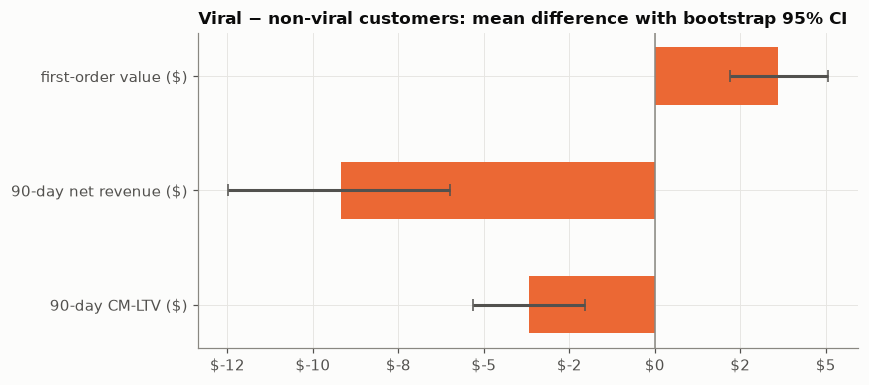

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.6))
d = res.loc[["90-day CM-LTV ($)", "90-day net revenue ($)", "first-order value ($)"]]
ax.barh(d.index, d["diff (viral − non)"], xerr=[d["diff (viral − non)"] - d["95% CI low"], d["95% CI high"] - d["diff (viral − non)"]],
        color=viz.VIRAL, height=0.5, capsize=4, error_kw={"ecolor": viz.INK2})
ax.axvline(0, color=viz.MUTED, linewidth=1); ax.xaxis.set_major_formatter(FuncFormatter(viz.money)); ax.set_title("Viral − non-viral customers: mean difference with bootstrap 95% CI")
plt.tight_layout(); plt.savefig("../images/06_effect_sizes.png"); plt.show()

## 2. Chi-square: repeat behaviour × virality

In [4]:
ct = pd.crosstab(cv.is_viral.map({0: "Non-viral", 1: "Viral"}), cv.repeat_90d.map({0: "no repeat", 1: "repeat ≤90d"}))
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(ct, f"\nchi² = {chi2:.1f}, dof = {dof}, p = {p:.2e}, Cramér's V = {np.sqrt(chi2 / len(cv)):.3f}")

repeat_90d  no repeat  repeat ≤90d
is_viral                          
Non-viral       18503        13305
Viral            5872         3267 
chi² = 108.7, dof = 1, p = 1.87e-25, Cramér's V = 0.052


## 3. Campaign level: what correlates with customer value?

Campaign-level Spearman correlations (cohorts with ≥ 30 customers) between engagement/campaign attributes and
90-day CM-LTV per customer, repeat rate and LTV:CAC.

In [5]:
big = cm[cm.new_customers >= 30].copy()
big["log_reach"] = np.log(big.reach)
big["is_macro_mega"] = big.creator_tier.isin(["Macro", "Mega"]).astype(int)
big["is_small_creator"] = big.creator_tier.isin(["Nano", "Micro"]).astype(int)
feats = ["log_reach", "share_rate", "save_rate", "save_to_share_ratio", "engagement_rate", "virality_score", "discount_pct", "is_macro_mega", "is_small_creator", "avg_first_order", "first_order_refund_rate"]
corr = big[feats + ["cm_90d_per_customer", "repeat_90d", "ltv_cac"]].corr("spearman").loc[feats, ["cm_90d_per_customer", "repeat_90d", "ltv_cac"]]
pv = pd.DataFrame({t: [stats.spearmanr(big[f], big[t]).pvalue for f in feats] for t in ["cm_90d_per_customer", "repeat_90d", "ltv_cac"]}, index=feats)
corr.round(2).astype(str) + pv.map(lambda p: " ***" if p < 0.001 else " **" if p < 0.01 else " *" if p < 0.05 else "")

,cm_90d_per_customer,repeat_90d,ltv_cac
log_reach,-0.1,-0.13,0.29 **
share_rate,-0.47 ***,-0.59 ***,-0.24 *
save_rate,0.47 ***,0.62 ***,0.54 ***
save_to_share_ratio,0.52 ***,0.67 ***,0.43 ***
engagement_rate,-0.1,-0.14,-0.04
virality_score,-0.35 ***,-0.46 ***,-0.02
discount_pct,-0.71 ***,-0.69 ***,-0.2 *
is_macro_mega,-0.09,-0.16,-0.23 *
is_small_creator,0.02,0.14,0.03
avg_first_order,0.77 ***,0.61 ***,0.37 ***


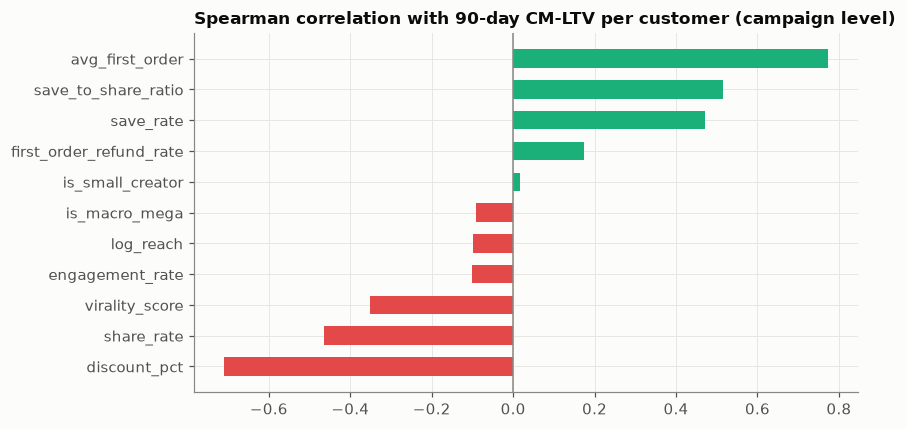

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
d = corr.cm_90d_per_customer.sort_values()
ax.barh(d.index, d.values, color=[viz.SERIES[2] if v > 0 else viz.SERIES[7] for v in d.values], height=0.6)
ax.axvline(0, color=viz.MUTED, linewidth=1); ax.set_title("Spearman correlation with 90-day CM-LTV per customer (campaign level)")
plt.tight_layout(); plt.savefig("../images/06_campaign_correlations.png"); plt.show()

**Save rate is positively related to customer value; share rate is negatively related.** Reach on its own is
close to zero; the virality score is negative only because it contains share rate. Discount depth is the
strongest negative; first-order value the strongest positive. Two engagement signals that both look like
"virality" point in opposite directions.

## 4. Multivariable regression at campaign level

OLS of 90-day CM-LTV per customer on the observable campaign attributes, weighted by cohort size. Reach is
included so we can see whether virality has any effect *after controlling for* the kind of content and offer.

In [7]:
def wls(X, y, w):
    X = np.column_stack([np.ones(len(X)), X]); W = np.diag(w)
    beta = np.linalg.solve(X.T @ W @ X, X.T @ W @ y)
    resid = y - X @ beta; dof = len(y) - X.shape[1]
    sigma2 = (w * resid ** 2).sum() / dof
    cov = sigma2 * np.linalg.inv(X.T @ W @ X); se = np.sqrt(np.diag(cov))
    t = beta / se; p = 2 * (1 - stats.t.cdf(np.abs(t), dof))
    r2 = 1 - (w * resid ** 2).sum() / (w * (y - np.average(y, weights=w)) ** 2).sum()
    return beta, se, p, r2

Xcols = ["log_reach", "share_rate", "save_rate", "discount_pct", "is_macro_mega", "is_small_creator"]
X = big[Xcols].copy(); X["share_rate"] *= 100; X["save_rate"] *= 100
beta, se, p, r2 = wls(X.values, big.cm_90d_per_customer.values, big.new_customers.values)
reg = pd.DataFrame({"coef": beta, "std err": se, "p": p}, index=["intercept"] + Xcols)
print(f"weighted R² = {r2:.2f}   (n = {len(big)} campaigns)")
reg.round(3)

weighted R² = 0.54   (n = 100 campaigns)


,coef,std err,p
intercept,80.126,19.126,0.000
log_reach,-2.053,1.525,0.181
share_rate,1.956,2.546,0.444
save_rate,12.505,2.380,0.000
discount_pct,-1.261,0.160,0.000
is_macro_mega,-2.774,4.100,0.500
is_small_creator,-1.872,5.099,0.714


Interpretation (units): each +1 percentage point of **save rate** adds roughly $12 of 90-day CM-LTV per
customer; each +1 point of **discount** removes about $1.30; and **neither log reach nor share rate is
significant** once save rate and discount are in the model. Creator tier is not significant at campaign level
(it is at customer level, below). Virality per se is not the driver — what the audience does with the content
(save vs share) and how it is monetised (discount) is.

## 5. Profitable virality vs vanity virality

Split viral campaigns by their **save-to-share ratio** (saves ÷ shares): above the viral-group median =
"save-led" virality (people bookmarking a product), below = "share-led" virality (people forwarding
entertainment or a discount code). The same split is applied within non-viral campaigns as a control.

In [8]:
# split within each group: viral campaigns have high share rates by construction, so a global median would
# classify every viral campaign as share-led; the question is *relative* mix of saving vs sharing.
med = cm.groupby("is_viral").save_to_share_ratio.transform("median")
cm["virality_kind"] = np.where(cm.save_to_share_ratio >= med, "save-led", "share-led")
print("median save-to-share ratio — non-viral: %.2f, viral: %.2f" % tuple(cm.groupby("is_viral").save_to_share_ratio.median()))
cvk = cv.merge(cm[["campaign_id", "virality_kind", "save_to_share_ratio"]], left_on="acquisition_campaign", right_on="campaign_id")
kind = cvk.groupby(["is_viral", "virality_kind"]).agg(customers=("customer_id", "size"), repeat_90d=("repeat_90d", "mean"), cm_ltv_90d=("cm_90d", "mean"),
                                                      first_order_refund=("first_order_refunded", "mean"), avg_discount_pct=("first_order_discount_pct", "mean"))
kind.index = kind.index.set_levels(["Non-viral", "Viral"], level=0)
kind.round(3)

median save-to-share ratio — non-viral: 1.75, viral: 0.27


customers  repeat_90d  cm_ltv_90d  first_order_refund  avg_discount_pct
is_viral  virality_kind                                                                         
Non-viral save-led           23322       0.450      62.290               0.110             6.045
          share-led           8486       0.332      46.080               0.102             9.351
Viral     save-led            6771       0.384      55.422               0.104             9.696
          share-led           2368       0.282      51.109               0.124             8.104

In [9]:
a = cvk[(cvk.is_viral == 1) & (cvk.virality_kind == "save-led")].cm_90d
b = cvk[(cvk.is_viral == 1) & (cvk.virality_kind == "share-led")].cm_90d
d, ci = bootstrap_mean_diff(a.values, b.values, n_boot=3000, seed=2)
print(f"Viral, save-led vs share-led: CM-LTV diff = ${d:.2f}  95% CI [{ci[0]:.2f}, {ci[1]:.2f}], Cliff's δ = {cliffs_delta(a, b):.3f}, MWU p = {stats.mannwhitneyu(a, b).pvalue:.2e}")
a2 = cvk[(cvk.is_viral == 0) & (cvk.virality_kind == "save-led")].cm_90d
b2 = cvk[(cvk.is_viral == 0) & (cvk.virality_kind == "share-led")].cm_90d
d2, ci2 = bootstrap_mean_diff(a2.values, b2.values, n_boot=3000, seed=3)
print(f"Non-viral, save-led vs share-led: CM-LTV diff = ${d2:.2f}  95% CI [{ci2[0]:.2f}, {ci2[1]:.2f}], Cliff's δ = {cliffs_delta(a2, b2):.3f}")

Viral, save-led vs share-led: CM-LTV diff = $4.29  95% CI [1.04, 7.62], Cliff's δ = 0.016, MWU p = 2.43e-01


Non-viral, save-led vs share-led: CM-LTV diff = $16.21  95% CI [14.58, 17.88], Cliff's δ = 0.153


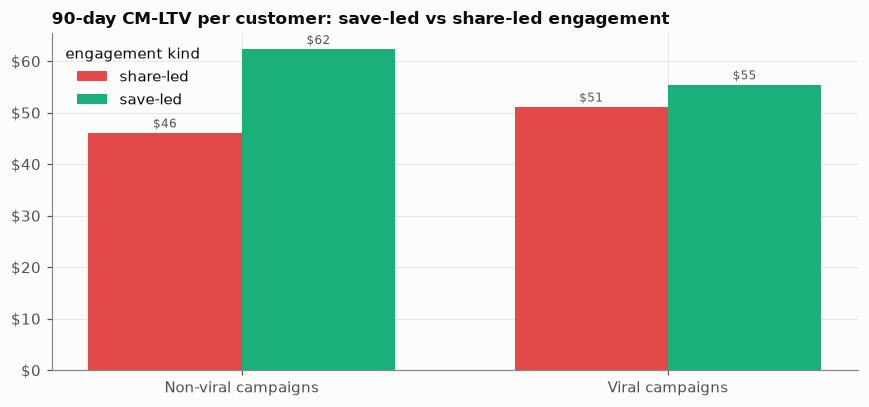

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.8))
x = np.arange(2); w = 0.36
for i, (k, col) in enumerate([("share-led", viz.SERIES[7]), ("save-led", viz.SERIES[2])]):
    vals = [kind.loc[("Non-viral", k), "cm_ltv_90d"], kind.loc[("Viral", k), "cm_ltv_90d"]]
    ax.bar(x + (i - 0.5) * w, vals, w, color=col, label=k)
    for xi, v in zip(x + (i - 0.5) * w, vals): ax.text(xi, v + 1, f"${v:.0f}", ha="center", fontsize=8, color=viz.INK2)
ax.set_xticks(x); ax.set_xticklabels(["Non-viral campaigns", "Viral campaigns"]); ax.yaxis.set_major_formatter(FuncFormatter(viz.money))
ax.set_title("90-day CM-LTV per customer: save-led vs share-led engagement"); ax.legend(title="engagement kind")
plt.tight_layout(); plt.savefig("../images/06_save_vs_share_led.png"); plt.show()

## 6. Customer-level regression: does virality matter after controlling for the offer?

Logistic regression of 90-day repeat on `is_viral` alone, then with first-order discount, creator tier,
first-order refund and value. If the `is_viral` coefficient shrinks toward zero, the "viral effect" is
composition, not causation.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def logit_coef(cols):
    Xd = pd.get_dummies(cv[cols], columns=[c for c in cols if not pd.api.types.is_numeric_dtype(cv[c])], drop_first=True, dtype=float)
    m = make_pipeline(StandardScaler(with_mean=False), LogisticRegression(max_iter=2000, C=1e6)).fit(Xd, cv.repeat_90d)
    sc = m.named_steps["standardscaler"].scale_
    return pd.Series(m.named_steps["logisticregression"].coef_[0] / sc, index=Xd.columns)  # back to raw units

m1 = logit_coef(["is_viral"])
m2 = logit_coef(["is_viral", "first_order_discount_pct", "first_order_refunded", "first_order_late", "first_order_value", "creator_tier", "first_order_category"])
print(f"is_viral log-odds, alone           : {m1['is_viral']:+.3f}   (odds ratio {np.exp(m1['is_viral']):.2f})")
print(f"is_viral log-odds, with controls   : {m2['is_viral']:+.3f}   (odds ratio {np.exp(m2['is_viral']):.2f})")
m2.round(3).to_frame("log-odds (raw units)")

is_viral log-odds, alone           : -0.256   (odds ratio 0.77)
is_viral log-odds, with controls   : -0.089   (odds ratio 0.91)


,log-odds (raw units)
is_viral,-0.089
first_order_discount_pct,-0.039
first_order_refunded,-0.872
first_order_late,-0.387
first_order_value,0.005
creator_tier_Macro,-0.622
creator_tier_Mega,-0.186
creator_tier_Micro,0.203
creator_tier_Mid,0.018
creator_tier_Nano,-0.532


## 7. Multiple comparisons and caveats

- We ran roughly a dozen tests; with n ≈ 40k customers, p-values are not the constraint — effect sizes are. A
  Bonferroni-adjusted α of 0.05/12 ≈ 0.004 changes none of the customer-level conclusions.
- Campaign-level tests use ~100 campaigns; treat those coefficients as directional.
- All results describe the **simulated** business (see `docs/methodology.md`). The structure of the finding —
  that engagement *type* and *offer* matter and raw reach does not — is the transferable lesson, not the dollar values.

In [12]:
res.to_csv("../data/processed/stats_viral_vs_nonviral.csv")
reg.to_csv("../data/processed/stats_campaign_regression.csv")
kind.to_csv("../data/processed/stats_save_vs_share_led.csv")

**Takeaways.**
- H0 is rejected: viral-acquired customers repeat less (−6 points at 90 days) and are worth a few dollars less
  in 90-day contribution margin — a real but **small** effect (Cliff's δ ≈ −0.02, Cramér's V ≈ 0.05).
- Once discount depth, creator tier, first-order experience and category are controlled, the odds ratio for
  `is_viral` moves from 0.77 to 0.91. Most of the "viral penalty" is **composition**: viral campaigns are
  disproportionately share-led, discount-driven and macro/mega-creator-led.
- Across the whole portfolio, **save-led campaigns produce customers worth ~$16 more** than share-led ones with
  a moderate effect size; within the eight viral campaigns the direction is the same but the sample is too small
  to be conclusive. The eight viral cohorts themselves span $28–$82 in CM-LTV.
- The actionable distinction is therefore not viral vs non-viral but **save-led, full-price, trusted-creator
  content vs share-led, discount-fuelled reach.**